#  read mongodb dataset
## read collections from db

In [ ]:
from pymongo import MongoClient
client = MongoClient("mongodb://localhost:27017")

db = client["Topology_Data"]
all_colls = db.list_collection_names()

print("All collections: ", all_colls)

## read topology from collection

In [ ]:
"""
查看 "Topology_Data" 数据库中 "real" 集合的所有数据集名称
"""

import NetworkToolkit as nt
import pymongo

# 方法 1：使用 read_data 读取所有文档的 name 字段，然后提取唯一值
def method1_read_all_names():
    """方法 1：读取所有文档并提取 name 字段的唯一值"""
    print("=" * 60)
    print("方法 1：读取所有文档并提取 name 字段")
    print("=" * 60)

    # 读取所有文档，只获取 name 字段
    results = nt.Database.read_data(
        "Topology_Data",
        "topology-paper",
        find_dic={},  # 空字典表示查询所有文档
        max_count=10000  # 设置一个足够大的值
    )

    # 提取所有 name 字段的值
    names = []
    for doc in results:
        if "name" in doc:
            names.append(doc["name"])

    # 获取唯一值并排序
    unique_names = sorted(set(names))

    print(f"\n找到 {len(unique_names)} 个唯一的数据集名称：")
    print("-" * 60)
    for i, name in enumerate(unique_names, 1):
        count = names.count(name)
        print(f"{i}. {name} (共 {count} 个文档)")

    return unique_names


# 方法 2：直接使用 MongoDB 的 distinct 方法
def method2_distinct():
    """方法 2：使用 MongoDB 的 distinct 命令获取唯一的 name 值"""
    print("\n" + "=" * 60)
    print("方法 2：使用 MongoDB distinct 命令")
    print("=" * 60)

    # 直接连接 MongoDB
    user = "robin_admin"
    pwd = "Focker_12UCL!"
    port = 27017

    client = pymongo.MongoClient('mongodb://localhost:{}'.format(port), username=user, password=pwd)
    db = client["Topology_Data"]
    collection = db["real"]

    # 使用 distinct 获取唯一的 name 值
    unique_names = sorted(collection.distinct("name"))

    print(f"\n找到 {len(unique_names)} 个唯一的数据集名称：")
    print("-" * 60)
    for i, name in enumerate(unique_names, 1):
        # 统计每个名称的文档数量
        count = collection.count_documents({"name": name})
        print(f"{i}. {name} (共 {count} 个文档)")

    client.close()
    return unique_names


# 方法 3：查看更详细的统计信息
def method3_detailed_info():
    """方法 3：查看每个数据集的详细信息"""
    print("\n" + "=" * 60)
    print("方法 3：详细统计信息")
    print("=" * 60)

    user = "robin_admin"
    pwd = "Focker_12UCL!"
    port = 27017

    client = pymongo.MongoClient('mongodb://localhost:{}'.format(port), username=user, password=pwd)
    db = client["Topology_Data"]
    collection = db["real"]

    # 获取所有唯一的 name 值
    unique_names = sorted(collection.distinct("name"))

    print(f"\n数据集详细统计：")
    print("=" * 60)

    for name in unique_names:
        docs = list(collection.find({"name": name}, {"nodes": 1, "edges": 1, "name": 1}))
        if len(docs) > 0:
            print(f"\n数据集名称: {name}")
            print(f"  文档数量: {len(docs)}")
            if "nodes" in docs[0]:
                nodes_list = [doc.get("nodes") for doc in docs if "nodes" in doc]
                if nodes_list:
                    print(f"  节点数范围: {min(nodes_list)} - {max(nodes_list)}")
            if "edges" in docs[0]:
                edges_list = [doc.get("edges") for doc in docs if "edges" in doc]
                if edges_list:
                    print(f"  边数范围: {min(edges_list)} - {max(edges_list)}")

    client.close()


if __name__ == "__main__":
    # 运行所有方法
    print("\n查看 'Topology_Data' 数据库中 'real' 集合的所有数据集")
    print("=" * 60)

    # 方法 1
    names1 = method1_read_all_names()

    # 方法 2（推荐，最快）
    names2 = method2_distinct()

    # 方法 3（详细统计）
    method3_detailed_info()

    print("\n" + "=" * 60)
    print("完成！")
    print("=" * 60)



## read graph

In [17]:
"""
检查数据库中存储的拓扑图信息，特别是经纬度坐标
修改下面的配置参数来检查不同的拓扑
"""

import NetworkToolkit as nt
import networkx as nx

# ============================================================
# 配置参数 - 在这里修改要检查的拓扑
# ============================================================
db = "Topology_Data"
collection = "real"
topology_name = "NSFNET"  # 修改这里：可以改为 "DTAG", "NSFNET", "CONUS" 等
# ============================================================

print("="*60)
print(f"Checking topology: {topology_name}")
print(f"Database: {db}.{collection}")
print("="*60)

# 1. 读取图数据
print("\n1. Reading graph from database...")
graph_list = nt.Database.read_topology_dataset_list(
    db, collection,
    find_dic={"name": topology_name},
    node_data=True,
    max_count=1
)

if len(graph_list) == 0:
    print(f"ERROR: No topology found with name '{topology_name}'")
else:
    graph, _id = graph_list[0]
    print(f"✓ Found topology with ID: {_id}")
    print(f"  Nodes: {len(graph.nodes())}")
    print(f"  Edges: {len(graph.edges())}")

    # 2. 检查节点属性
    print("\n2. Checking node attributes...")
    sample_nodes = list(graph.nodes())[:3]  # 检查前3个节点
    for node in sample_nodes:
        attrs = graph.nodes[node]
        print(f"\n  Node {node}:")
        print(f"    Attributes: {list(attrs.keys())}")
        if attrs:
            print(f"    Values: {attrs}")

    # 检查所有节点是否有经纬度属性
    lat_keys = ['Latitude', 'latitude', 'lat', 'Lat']
    lon_keys = ['Longitude', 'longitude', 'lon', 'Lon', 'lng', 'Lng']

    has_geo_all = True
    lat_key_found = None
    lon_key_found = None

    for node in graph.nodes():
        node_attrs = graph.nodes[node]
        # 检查是否有经纬度属性
        has_lat = any(key in node_attrs for key in lat_keys)
        has_lon = any(key in node_attrs for key in lon_keys)

        if has_lat and has_lon:
            if lat_key_found is None:
                for key in lat_keys:
                    if key in node_attrs:
                        lat_key_found = key
                        break
            if lon_key_found is None:
                for key in lon_keys:
                    if key in node_attrs:
                        lon_key_found = key
                        break
        else:
            has_geo_all = False
            break

    if has_geo_all and lat_key_found and lon_key_found:
        print(f"\n  ✓ Geographic coordinates found: {lat_key_found}, {lon_key_found}")
        # 显示坐标范围
        lats = [graph.nodes[node][lat_key_found] for node in graph.nodes()]
        lons = [graph.nodes[node][lon_key_found] for node in graph.nodes()]
        print(f"    Latitude range: {min(lats):.4f} - {max(lats):.4f}")
        print(f"    Longitude range: {min(lons):.4f} - {max(lons):.4f}")
    else:
        print(f"\n  ✗ Geographic coordinates NOT found in node attributes")

    # 3. 检查数据库文档中的原始数据
    print("\n3. Checking raw database document...")
    try:
        results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
        if len(results) > 0:
            doc = results[0]
            print(f"  Document keys: {list(doc.keys())}")

            # 检查是否有 node data 字段
            if "node data" in doc:
                print(f"\n  ✓ 'node data' field exists")
                node_data = doc["node data"]
                print(f"    Type: {type(node_data)}")

                # 如果是字典，检查第一个节点的数据
                if isinstance(node_data, dict):
                    first_node_key = list(node_data.keys())[0] if node_data else None
                    if first_node_key:
                        first_node_data = node_data[first_node_key]
                        print(f"    Sample node ({first_node_key}) data: {first_node_data}")
                        print(f"    Sample node data keys: {list(first_node_data.keys()) if isinstance(first_node_data, dict) else 'N/A'}")
            else:
                print(f"  ✗ 'node data' field NOT found")

            # 检查是否有其他相关字段
            geo_related_keys = [key for key in doc.keys() if any(term in key.lower() for term in ['geo', 'lat', 'lon', 'coord', 'location'])]
            if geo_related_keys:
                print(f"\n  Geographic-related fields found: {geo_related_keys}")

            # 显示其他重要字段
            important_fields = ["name", "nodes", "edges", "description", "country"]
            print(f"\n  Other important fields:")
            for field in important_fields:
                if field in doc:
                    print(f"    {field}: {doc[field]}")
        else:
            print("  ✗ Could not read document from database")
    except Exception as e:
        print(f"  ✗ Error reading document: {e}")

    # 4. 尝试读取节点数据（使用 Tools）
    print("\n4. Checking node data using NetworkToolkit Tools...")
    try:
        results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
        if len(results) > 0 and "node data" in results[0]:
            node_data_raw = results[0]["node data"]
            node_data_dict = nt.Tools.read_database_node_data(node_data_raw, use_pickle=False)

            print(f"  ✓ Successfully parsed node data")
            print(f"    Number of nodes with data: {len(node_data_dict)}")

            # 检查第一个节点的数据
            if node_data_dict:
                first_node = list(node_data_dict.keys())[0]
                first_node_attrs = node_data_dict[first_node]
                print(f"\n    Sample node ({first_node}) attributes:")
                print(f"      Keys: {list(first_node_attrs.keys())}")
                print(f"      Values: {first_node_attrs}")

                # 检查是否有经纬度
                has_lat = any(key in first_node_attrs for key in lat_keys)
                has_lon = any(key in first_node_attrs for key in lon_keys)
                if has_lat and has_lon:
                    print(f"      ✓ Has geographic coordinates!")
                else:
                    print(f"      ✗ No geographic coordinates found")
        else:
            print("  ✗ Could not parse node data")
    except Exception as e:
        print(f"  ✗ Error parsing node data: {e}")

    print("\n" + "="*60)
    print("Summary:")
    print("="*60)
    print(f"Topology: {topology_name}")
    print(f"Nodes: {len(graph.nodes())}")
    print(f"Edges: {len(graph.edges())}")
    if has_geo_all and lat_key_found and lon_key_found:
        print(f"Geographic coordinates: ✓ Available ({lat_key_found}, {lon_key_found})")
    else:
        print(f"Geographic coordinates: ✗ NOT available")
    print("="*60)

Checking topology: NSFNET
Database: Topology_Data.real

1. Reading graph from database...


reading data in real: 1it [00:00,  3.44it/s]

✓ Found topology with ID: 5f636b15439c64afe20d6f6f
  Nodes: 14
  Edges: 21

2. Checking node attributes...

  Node 1:
    Attributes: ['degree', 'clustering coefficient', 'traffic']
    Values: {'degree': 3, 'clustering coefficient': 0.3333333333333333, 'traffic': 0.07142857142857142}

  Node 2:
    Attributes: ['degree', 'clustering coefficient', 'traffic']
    Values: {'degree': 3, 'clustering coefficient': 0.3333333333333333, 'traffic': 0.07142857142857142}

  Node 3:
    Attributes: ['degree', 'clustering coefficient', 'traffic']
    Values: {'degree': 3, 'clustering coefficient': 0.3333333333333333, 'traffic': 0.07142857142857142}

  ✗ Geographic coordinates NOT found in node attributes

3. Checking raw database document...
  Document keys: ['_id', 'connectivity', 'topology vector', 'D FF_kSP', 'D ILP', 'D upper bound', 'D lower bound', 'algebraic connectivity', 'cheeger constant', 'total network capacity ILP', 'total network capacity FF_kSP', 'chromatic number', 'RWA density ILP'

# draw topology

Reading topology from database: Topology_Data.real
Query: {'name': 'NSFNET'}


reading data in real: 1it [00:00,  7.69it/s]

DEBUG plot_topology_from_database: Sample node 1 has 0 attributes: []
DEBUG: Manually loaded and merged node data from database
DEBUG: After loading, sample node 1 has attributes: []

Topology Information:
  ID: 5f636b15439c64afe20d6f6f
  Number of Nodes: 14
  Number of Edges: 21
  Average Degree: 3.00
  Geographic coordinates not found in node attributes
  Sample node attributes: []


  Attempting to load node data from database document...
  ✓ Loaded node data for 14 nodes from database
  ✓ Geographic coordinates now available (Latitude, Longitude)
  Geographic coordinates: Available (Latitude, Longitude)
  Edge weights: Available (min=5, max=45, avg=18.67)
DEBUG get_node_positions: Sample node 1 attributes: ['degree', 'clustering coefficient', 'traffic', 'Latitude', 'Longitude', 'latitude', 'longitude', 'city']
DEBUG get_node_positions: Sample node 1 attribute values: {'degree': '3', 'clustering coefficient': '0.3333333333333333', 'traffic': '0.07142857142857142', 'Latitude': '47.6062', 'Longitude': '-122.3321', 'latitude': '47.6062', 'longitude': '-122.3321', 'city': 'Seattle'}
DEBUG: Checking node 1, attributes: ['degree', 'clustering coefficient', 'traffic', 'Latitude', 'Longitude', 'latitude', 'longitude', 'city']
DEBUG: Found latitude key: Latitude in node 1
DEBUG: Found longitude key: Longitude in node 1
DEBUG: Using keys: Latitude, Longitude
DEBUG: Nodes wi

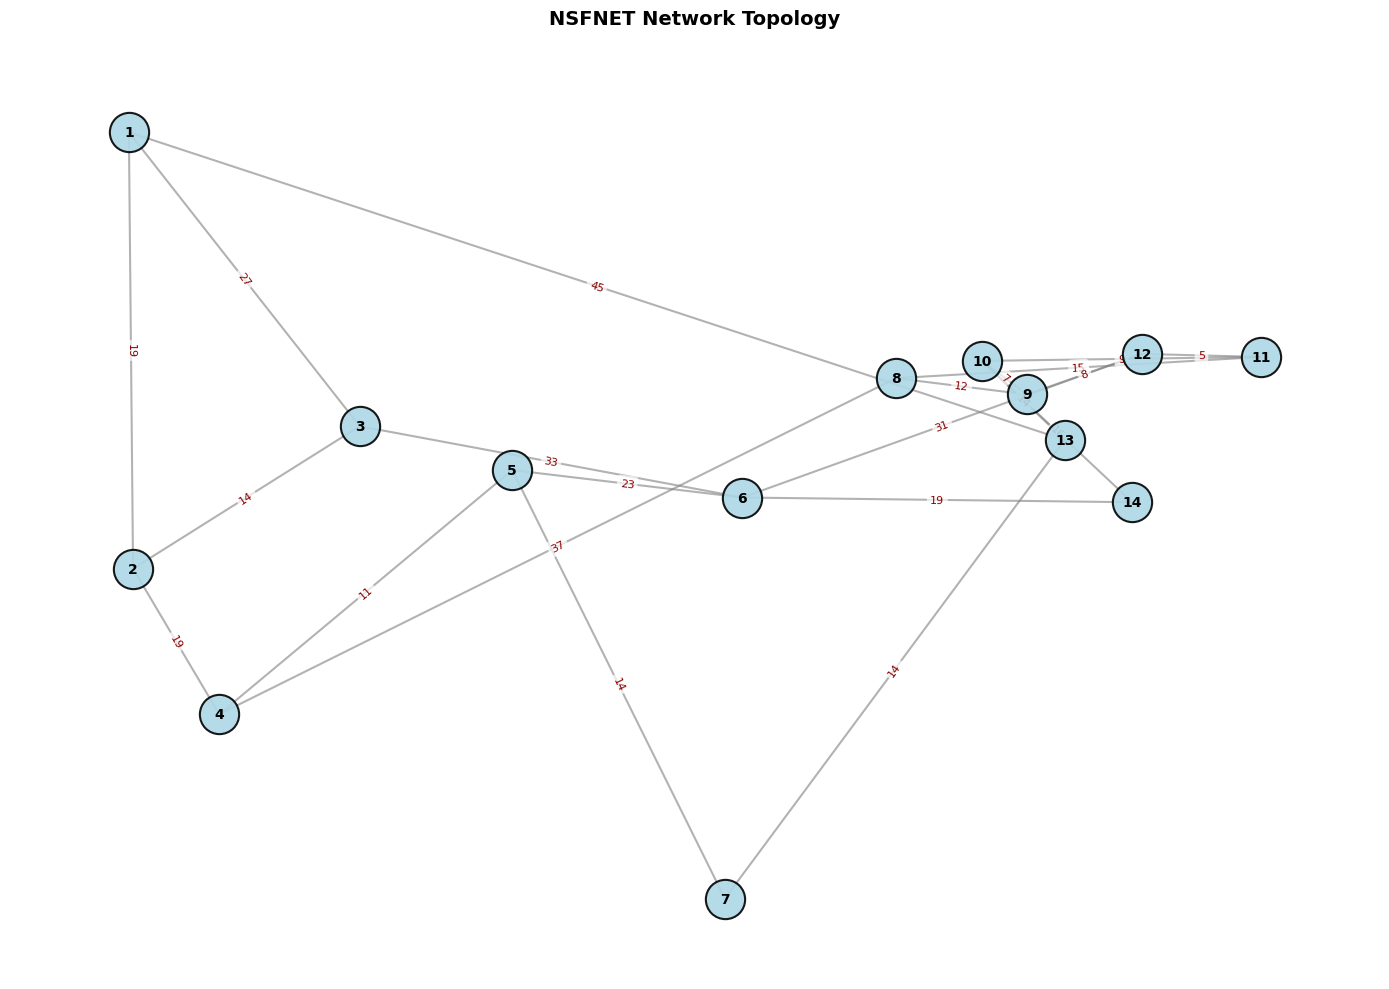

In [26]:
"""
拓扑图可视化工具
从MongoDB读取拓扑数据并绘制网络拓扑图
支持显示节点标签、边权重、地理坐标等
"""

import NetworkToolkit as nt
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional, Dict, List, Tuple


def get_node_positions(graph, use_geographic=True, debug=False):
    """
    获取节点位置（用于绘图布局）

    Parameters:
    -----------
    graph : networkx.Graph
        网络拓扑图
    use_geographic : bool
        是否使用地理坐标（如果可用）
    debug : bool
        是否打印调试信息

    Returns:
    --------
    pos : dict
        节点位置字典，格式：{node: (x, y)}
    """
    pos = {}

    if use_geographic:
        # 检查节点属性（尝试多种可能的属性名）
        sample_node = list(graph.nodes())[0] if len(graph.nodes()) > 0 else None
        if sample_node is not None:
            node_attrs = graph.nodes[sample_node]
            if debug:
                print(f"DEBUG get_node_positions: Sample node {sample_node} attributes: {list(node_attrs.keys())}")
                print(f"DEBUG get_node_positions: Sample node {sample_node} attribute values: {node_attrs}")
        
        # 尝试多种可能的属性名格式
        lat_keys = ['Latitude', 'latitude', 'lat', 'Lat']
        lon_keys = ['Longitude', 'longitude', 'lon', 'Lon', 'lng', 'Lng']
        
        # 找到实际使用的属性名
        lat_key = None
        lon_key = None
        
        # 检查所有节点，找到第一个有经纬度的节点
        for node in graph.nodes():
            node_attrs = graph.nodes[node]
            if debug and node == sample_node:
                print(f"DEBUG: Checking node {node}, attributes: {list(node_attrs.keys())}")
            
            for lat_k in lat_keys:
                if lat_k in node_attrs:
                    lat_key = lat_k
                    if debug:
                        print(f"DEBUG: Found latitude key: {lat_k} in node {node}")
                    break
            for lon_k in lon_keys:
                if lon_k in node_attrs:
                    lon_key = lon_k
                    if debug:
                        print(f"DEBUG: Found longitude key: {lon_k} in node {node}")
                    break
            if lat_key and lon_key:
                break
        
        if lat_key and lon_key:
            if debug:
                print(f"DEBUG: Using keys: {lat_key}, {lon_key}")
            
            # 检查所有节点是否都有这些属性
            nodes_with_coords = []
            nodes_without_coords = []
            for node in graph.nodes():
                has_lat = lat_key in graph.nodes[node]
                has_lon = lon_key in graph.nodes[node]
                if has_lat and has_lon:
                    nodes_with_coords.append(node)
                else:
                    nodes_without_coords.append(node)
            
            if debug:
                print(f"DEBUG: Nodes with coordinates: {len(nodes_with_coords)}/{len(graph.nodes())}")
                if nodes_without_coords:
                    print(f"DEBUG: Nodes without coordinates: {nodes_without_coords[:5]}...")
            
            if len(nodes_with_coords) == len(graph.nodes()):
                # 所有节点都有坐标
                for node in graph.nodes():
                    # 处理可能的字符串格式（从数据库读取时可能是字符串）
                    lat = graph.nodes[node].get(lat_key, 0)
                    lon = graph.nodes[node].get(lon_key, 0)
                    
                    # 如果是字符串，尝试转换
                    if isinstance(lat, str):
                        try:
                            import ast
                            lat = ast.literal_eval(lat)
                        except:
                            try:
                                lat = float(lat)
                            except:
                                lat = 0
                    
                    if isinstance(lon, str):
                        try:
                            import ast
                            lon = ast.literal_eval(lon)
                        except:
                            try:
                                lon = float(lon)
                            except:
                                lon = 0
                    
                    pos[node] = (float(lon), float(lat))  # 注意：x=经度，y=纬度
                
                if debug:
                    print(f"DEBUG: Using geographic coordinates: {lat_key}, {lon_key}")
                    print(f"DEBUG: Coordinate range: lon=[{min(p[0] for p in pos.values()):.2f}, {max(p[0] for p in pos.values()):.2f}], "
                          f"lat=[{min(p[1] for p in pos.values()):.2f}, {max(p[1] for p in pos.values()):.2f}]")
                    print(f"DEBUG: Sample positions: {dict(list(pos.items())[:3])}")
                
                return pos
            else:
                if debug:
                    print(f"DEBUG: Found {lat_key} and {lon_key} but only {len(nodes_with_coords)}/{len(graph.nodes())} nodes have these attributes")
                    print(f"DEBUG: Missing coordinates in nodes: {nodes_without_coords}")
        else:
            if debug:
                print("DEBUG: No geographic coordinate attributes found in nodes")
                if sample_node:
                    print(f"DEBUG: Available attributes in sample node: {list(graph.nodes[sample_node].keys())}")
                    # 打印所有节点的属性键（去重）
                    all_keys = set()
                    for node in graph.nodes():
                        all_keys.update(graph.nodes[node].keys())
                    print(f"DEBUG: All attribute keys found across nodes: {sorted(all_keys)}")

    # 如果没有地理坐标，使用自动布局
    if debug:
        print("DEBUG: Using automatic layout (spring_layout) - geographic coordinates not available")
    
    # 尝试使用spring布局（力导向布局）
    try:
        pos = nx.spring_layout(graph, k=1, iterations=50)
    except:
        # 如果spring布局失败，使用circular布局
        pos = nx.circular_layout(graph)

    return pos


def plot_topology(graph, title="Network Topology", save_path=None,
                  show_node_labels=True, show_edge_labels=False,
                  show_edge_weights=False, node_size=500,
                  node_color='lightblue', edge_color='gray',
                  figsize=(12, 8), use_geographic=True,
                  font_size=10, edge_width=1.5, debug=False):
    """
    绘制网络拓扑图

    Parameters:
    -----------
    graph : networkx.Graph
        网络拓扑图
    title : str
        图标题
    save_path : str, optional
        保存路径（如 "topology.png"）
    show_node_labels : bool
        是否显示节点标签
    show_edge_labels : bool
        是否显示边标签（边ID）
    show_edge_weights : bool
        是否显示边权重
    node_size : int
        节点大小
    node_color : str
        节点颜色
    edge_color : str
        边颜色
    figsize : tuple
        图像大小
    use_geographic : bool
        是否使用地理坐标（如果可用）
    font_size : int
        字体大小
    edge_width : float
        边宽度

    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
    # 创建图形
    plt.style.use('default')

    fig, ax = plt.subplots(figsize=figsize)

    # 获取节点位置
    pos = get_node_positions(graph, use_geographic=use_geographic, debug=debug)

    # 绘制边
    nx.draw_networkx_edges(graph, pos, ax=ax,
                           edge_color=edge_color,
                           width=edge_width,
                           alpha=0.6)

    # 绘制节点
    nx.draw_networkx_nodes(graph, pos, ax=ax,
                           node_size=node_size,
                           node_color=node_color,
                           alpha=0.9,
                           edgecolors='black',
                           linewidths=1.5)

    # 绘制节点标签
    if show_node_labels:
        nx.draw_networkx_labels(graph, pos, ax=ax,
                                font_size=font_size,
                                font_weight='bold',
                                font_color='black')

    # 绘制边标签（权重或边ID）
    if show_edge_labels or show_edge_weights:
        edge_labels = {}
        for edge in graph.edges():
            if show_edge_weights and 'weight' in graph[edge[0]][edge[1]]:
                weight = graph[edge[0]][edge[1]]['weight']
                edge_labels[edge] = f"{weight}"
            elif show_edge_labels:
                edge_labels[edge] = f"{edge[0]}-{edge[1]}"

        if edge_labels:
            nx.draw_networkx_edge_labels(graph, pos, edge_labels, ax=ax,
                                         font_size=font_size-2,
                                         font_color='darkred',
                                         bbox=dict(boxstyle='round,pad=0.3',
                                                   facecolor='white',
                                                   alpha=0.7,
                                                   edgecolor='none'))

    # 设置标题和坐标轴
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')  # 关闭坐标轴

    # 调整布局
    plt.tight_layout()

    # 保存图片
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Topology plot saved to: {save_path}")

    return fig, ax


def plot_topology_from_database(db="Topology_Data", collection="topology-paper",
                                find_dic=None, title=None, save_path=None,
                                max_count=1, use_geographic=True,
                                show_node_labels=True, show_edge_weights=True,
                                **plot_kwargs):
    """
    从MongoDB数据库读取拓扑并绘制

    Parameters:
    -----------
    db : str
        数据库名称
    collection : str
        集合名称
    find_dic : dict, optional
        MongoDB查询条件，例如 {"name": "NSFNET"}
    title : str, optional
        图标题（如果不指定，使用拓扑名称或ID）
    save_path : str, optional
        保存路径
    max_count : int
        最大读取数量（如果多个匹配，只绘制第一个）
    use_geographic : bool
        是否使用地理坐标
    show_node_labels : bool
        是否显示节点标签
    show_edge_weights : bool
        是否显示边权重
    **plot_kwargs : dict
        传递给plot_topology的其他参数

    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
    # 读取拓扑数据
    if find_dic is None:
        find_dic = {}

    print(f"Reading topology from database: {db}.{collection}")
    print(f"Query: {find_dic}")

    graph_list = nt.Database.read_topology_dataset_list(
        db, collection,
        find_dic=find_dic,
        node_data=True,  # 确保读取节点数据
        max_count=max_count
    )

    if len(graph_list) == 0:
        raise ValueError(f"No topology found matching query: {find_dic}")

    # 获取第一个拓扑
    graph, _id = graph_list[0]
    
    # 从 plot_kwargs 中提取 debug 参数（提前提取以便使用）
    debug_mode = plot_kwargs.pop('debug', False)
    
    # 如果节点数据没有正确加载，尝试手动加载
    # 检查是否有节点属性
    sample_node = list(graph.nodes())[0] if len(graph.nodes()) > 0 else None
    if sample_node:
        sample_attrs = graph.nodes[sample_node]
        if debug_mode:
            print(f"DEBUG plot_topology_from_database: Sample node {sample_node} has {len(sample_attrs)} attributes: {list(sample_attrs.keys())}")
        
        # 如果节点属性很少或没有经纬度，尝试手动加载
        lat_keys = ['Latitude', 'latitude', 'lat', 'Lat']
        lon_keys = ['Longitude', 'longitude', 'lon', 'Lon', 'lng', 'Lng']
        has_geo_in_sample = any(key in sample_attrs for key in lat_keys) and any(key in sample_attrs for key in lon_keys)
        
        if not has_geo_in_sample and len(sample_attrs) < 5:  # 如果属性很少，可能没有正确加载
            # 尝试从数据库手动加载节点数据
            try:
                results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
                if len(results) > 0 and "node data" in results[0]:
                    node_data_raw = results[0]["node data"]
                    node_data_dict = nt.Tools.read_database_node_data(node_data_raw, use_pickle=False)
                    # 将节点数据添加到图中（合并，不覆盖现有属性）
                    for node, attrs in node_data_dict.items():
                        if node in graph.nodes():
                            graph.nodes[node].update(attrs)
                    if debug_mode:
                        print(f"DEBUG: Manually loaded and merged node data from database")
                        print(f"DEBUG: After loading, sample node {sample_node} has attributes: {list(graph.nodes[sample_node].keys())}")
            except Exception as e:
                if debug_mode:
                    print(f"DEBUG: Could not manually load node data: {e}")
                    import traceback
                    traceback.print_exc()

    # 打印拓扑信息
    print(f"\nTopology Information:")
    print(f"  ID: {_id}")
    print(f"  Number of Nodes: {len(graph.nodes)}")
    print(f"  Number of Edges: {len(graph.edges)}")
    print(f"  Average Degree: {2 * len(graph.edges) / len(graph.nodes):.2f}")

    # 检查是否有地理坐标（更灵活的检查）
    lat_keys = ['Latitude', 'latitude', 'lat', 'Lat']
    lon_keys = ['Longitude', 'longitude', 'lon', 'Lon', 'lng', 'Lng']
    
    lat_key = None
    lon_key = None
    sample_node = list(graph.nodes())[0] if len(graph.nodes()) > 0 else None
    
    if sample_node:
        for lat_k in lat_keys:
            if lat_k in graph.nodes[sample_node]:
                lat_key = lat_k
                break
        for lon_k in lon_keys:
            if lon_k in graph.nodes[sample_node]:
                lon_key = lon_k
                break
    
    has_geo = (lat_key and lon_key and 
               all(lat_key in graph.nodes[node] and lon_key in graph.nodes[node]
                   for node in graph.nodes()))
    
    # 如果节点属性中没有经纬度，尝试从数据库文档中手动加载
    if not has_geo:
        print(f"  Geographic coordinates not found in node attributes")
        if sample_node:
            print(f"  Sample node attributes: {list(graph.nodes[sample_node].keys())}")
        
        # 尝试从数据库文档中读取节点数据
        try:
            results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
            if len(results) > 0 and "node data" in results[0]:
                print(f"  Attempting to load node data from database document...")
                node_data_raw = results[0]["node data"]
                node_data_dict = nt.Tools.read_database_node_data(node_data_raw, use_pickle=False)
                
                if node_data_dict:
                    print(f"  ✓ Loaded node data for {len(node_data_dict)} nodes from database")
                    # 将节点数据合并到图中
                    for node_id, node_attrs in node_data_dict.items():
                        # 确保节点ID匹配（可能是字符串或整数）
                        node_id_int = int(node_id) if isinstance(node_id, str) and str(node_id).isdigit() else node_id
                        if node_id_int in graph.nodes():
                            # 合并属性（不覆盖现有属性）
                            for key, value in node_attrs.items():
                                if key not in graph.nodes[node_id_int]:
                                    graph.nodes[node_id_int][key] = value
                    
                    # 重新检查是否有经纬度
                    lat_key = None
                    lon_key = None
                    if sample_node:
                        for lat_k in lat_keys:
                            if lat_k in graph.nodes[sample_node]:
                                lat_key = lat_k
                                break
                        for lon_k in lon_keys:
                            if lon_k in graph.nodes[sample_node]:
                                lon_key = lon_k
                                break
                    
                    has_geo = (lat_key and lon_key and 
                               all(lat_key in graph.nodes[node] and lon_key in graph.nodes[node]
                                   for node in graph.nodes()))
                    
                    if has_geo:
                        print(f"  ✓ Geographic coordinates now available ({lat_key}, {lon_key})")
                    else:
                        print(f"  ✗ Still no geographic coordinates found after loading node data")
                        if sample_node:
                            print(f"    Sample node attributes after load: {list(graph.nodes[sample_node].keys())}")
                else:
                    print(f"  ✗ Could not parse node data from database")
        except Exception as e:
            print(f"  ✗ Error loading node data from database: {e}")
            import traceback
            traceback.print_exc()
    
    if has_geo:
        print(f"  Geographic coordinates: Available ({lat_key}, {lon_key})")
    else:
        print(f"  Geographic coordinates: Not available (using automatic layout)")

    # 检查边权重
    has_weights = all('weight' in graph[edge[0]][edge[1]] for edge in graph.edges())
    if has_weights:
        weights = [graph[edge[0]][edge[1]]['weight'] for edge in graph.edges()]
        print(f"  Edge weights: Available (min={min(weights)}, max={max(weights)}, avg={np.mean(weights):.2f})")
    else:
        print(f"  Edge weights: Not available")

    # 确定标题
    if title is None:
        # 尝试从数据库获取名称
        try:
            results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
            if len(results) > 0 and "name" in results[0]:
                title = f"{results[0]['name']} Network Topology"
            else:
                title = f"Network Topology (ID: {_id})"
        except:
            title = f"Network Topology (ID: {_id})"

    # 确定保存路径
    if save_path is None:
        topology_name = title.replace(" ", "_").replace("(", "").replace(")", "").replace(":", "")
        save_path = f"{topology_name.lower()}.png"

    # 绘制拓扑（传递debug参数）
    # debug_mode 已经在前面提取了
    fig, ax = plot_topology(
        graph,
        title=title,
        save_path=save_path,
        use_geographic=use_geographic,
        show_node_labels=show_node_labels,
        show_edge_weights=show_edge_weights,
        debug=debug_mode,
        **plot_kwargs
    )

    return fig, ax, graph


def plot_multiple_topologies(db="Topology_Data", collection="topology-paper",
                             find_dic=None, max_count=10,
                             save_dir="topology_plots", **plot_kwargs):
    """
    批量绘制多个拓扑图

    Parameters:
    -----------
    db : str
        数据库名称
    collection : str
        集合名称
    find_dic : dict, optional
        MongoDB查询条件
    max_count : int
        最大读取数量
    save_dir : str
        保存目录
    **plot_kwargs : dict
        传递给plot_topology的参数

    Returns:
    --------
    results : list
        绘制结果列表
    """
    import os

    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)

    # 读取拓扑列表
    graph_list = nt.Database.read_topology_dataset_list(
        db, collection,
        find_dic=find_dic or {},
        node_data=True,
        max_count=max_count
    )

    print(f"Found {len(graph_list)} topologies to plot")

    results = []
    for i, (graph, _id) in enumerate(graph_list):
        print(f"\nPlotting topology {i+1}/{len(graph_list)} (ID: {_id})")

        # 确定标题和保存路径
        try:
            results_data = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
            if len(results_data) > 0 and "name" in results_data[0]:
                title = f"{results_data[0]['name']} Network Topology"
                save_path = os.path.join(save_dir, f"{results_data[0]['name'].replace(' ', '_')}.png")
            else:
                title = f"Network Topology (ID: {_id})"
                save_path = os.path.join(save_dir, f"topology_{_id}.png")
        except:
            title = f"Network Topology (ID: {_id})"
            save_path = os.path.join(save_dir, f"topology_{_id}.png")

        # 绘制
        try:
            fig, ax = plot_topology(graph, title=title, save_path=save_path, **plot_kwargs)
            results.append((_id, save_path, True))
            plt.close(fig)  # 关闭图形以释放内存
        except Exception as e:
            print(f"Error plotting topology {_id}: {e}")
            results.append((_id, None, False))

    print(f"\nCompleted! Plotted {sum(1 for _, _, success in results if success)}/{len(results)} topologies")
    return results


if __name__ == "__main__":
    # ============================================================
    # 示例1：绘制NSFNET拓扑
    # ============================================================
    print("="*60)
    # print("Example 1: Plot NSFNET Topology")
    print("="*60)
    # db="Topology_Data",
    # collection="topology-paper",
    # find_dic={"name": "nobel-germany"},
    try:
        fig, ax, graph = plot_topology_from_database(
            db="Topology_Data",
            collection="real",
            find_dic={"name": "NSFNET"},  # 改为 DTAG 来测试
            title="NSFNET Network Topology",
            save_path="NSFNET_topology.png",
            use_geographic=True,
            show_node_labels=True,
            show_edge_weights=True,
            node_size=800,
            figsize=(14, 10),
            debug=True  # 启用调试模式以查看坐标信息
        )
        plt.show()
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

    # ============================================================
    # 示例2：批量绘制多个拓扑（可选）
    # ============================================================
    # print("\n" + "="*60)
    # print("Example 2: Plot Multiple Topologies")
    # print("="*60)
    #
    # results = plot_multiple_topologies(
    #     db="Topology_Data",
    #     collection="topology-paper",
    #     find_dic={"nodes": 14},
    #     max_count=5,
    #     save_dir="topology_plots",
    #     show_node_labels=True,
    #     show_edge_weights=False
    # )


# create collections from db

In [ ]:
import NetworkToolkit as nt
import networkx as nx
import numpy as np

graph = nx.Graph()
graph.add_node(1)
graph.add_node(2)

graph.add_edge(1,2, weight = 10)

graph.nodes[1]["label"] = "A"
graph.nodes[2]["label"] = "B"

extra_data = {

    "name": "P2P_test",
    "nodes": graph.number_of_nodes(),
    "edges": graph.number_of_edges(),
    "description": "2-node point to point test topology with 10 spans"
}

db_name = "Topology_Data"
collection_name = "p2p_test"
#
inserted_id = nt.Database.insert_graph(
    graph,
    db_name,
    collection_name,
    node_data=True,          # 关键：保存节点属性
    **extra_data
)

print("Inserted topology with _id", inserted_id)





## read graph id

In [ ]:
graph_list = nt.Database.read_topology_dataset_list(
    db_name,
    collection_name,
    find_dic={"name": "DTAG"},
    node_data=True
)

# graph_list 里的每一项一般是 (graph, _id, 其他字段...)
graph, _id, *rest = graph_list[0]
print(graph.nodes(), graph.edges(), _id)


# delete collection

In [2]:
from pymongo import MongoClient
client = MongoClient("mongodb://localhost:27017")  # PORT 换成 NetworkToolkit 里用的端口
# db = client["Topology_Data"]
# coll = db["real"]
# # topology_{band}_distance_scaling_{dic}
# coll.delete_many({"name": "DTAG"})  # 删掉所有旧的 P2P_test
band = "C"
dic = "NSFNET"
db = client["Topology_Data"]
coll = db[f"topology_{band}_distance_scaling_{dic}"]
# topology_{band}_distance_scaling_{dic}
coll.delete_many({"name": dic})  # 删掉所有旧的 P2P_test


DeleteResult({'n': 0, 'ok': 1.0}, acknowledged=True)

# read topology information in specific collection

In [ ]:
import NetworkToolkit as nt
import numpy as np

# 从数据库读取结果
db_name = "Topology_Data"
collection_name = "topology_paper_distance_scaling"  # 你修改后的 collection 名称

# 读取所有缩放结果
results = list(nt.Database.read_data(
    db_name,
    collection_name,
    find_dic={},  # 读取所有
    max_count=100
))

print(f"Found {len(results)} scaling results in database\n")

# 显示每个结果的关键信息
for i, result in enumerate(results):
    print("="*60)
    print(f"Result {i+1}")
    print("="*60)

    # 基本信息
    if "_id" in result:
        print(f"Document ID: {result['_id']}")
    if "name" in result:
        print(f"Topology Name: {result['name']}")
    if "scale" in result:
        print(f"Scale Factor: {result['scale']}")
    if "nodes" in result:
        print(f"Number of Nodes: {result['nodes']}")
    if "edges" in result:
        print(f"Number of Edges: {result['edges']}")

    # RWA 信息
    if "original ILP capacity RWA" in result:
        rwa = result["original ILP capacity RWA"]
        # 如果是字符串，需要转换
        if isinstance(rwa, str):
            import ast
            rwa = ast.literal_eval(rwa)

        # 统计光路数量
        total_lightpaths = sum(len(paths) for paths in rwa.values())
        print(f"Total Lightpaths: {total_lightpaths}")
        print(f"Number of Wavelengths Used: {len([w for w in rwa.keys() if rwa[w]])}")

    # 吞吐量
    if "ilp_throughput" in result:
        throughput = result["ilp_throughput"]
        print(f"Throughput: {throughput:.2e} bps ({throughput/1e12:.4f} Tbps)")

    # 时间戳
    if "erratum timestamp" in result:
        print(f"Timestamp: {result['erratum timestamp']}")

    print()

# 按拓扑名称和缩放因子分组统计
print("\n" + "="*60)
print("Summary by Topology and Scale")
print("="*60)

from collections import defaultdict
summary = defaultdict(list)

for result in results:
    name = result.get("name", "Unknown")
    scale = result.get("scale", "Unknown")
    throughput = result.get("ilp_throughput", 0)
    summary[(name, scale)].append(throughput)

for (name, scale), throughputs in sorted(summary.items()):
    if throughputs:
        avg_throughput = np.mean(throughputs)
        print(f"{name} (scale={scale}): {avg_throughput:.2e} bps ({avg_throughput/1e12:.4f} Tbps)")

# write a topology (DTAG) to real collection in Topology_Data

In [2]:
import NetworkToolkit as nt
import networkx as nx
import numpy as np

# ============================================================
# 创建 DTAG/T-Systems 拓扑
# ============================================================
nodes = {
    'BR': 'Bremen', 'HG': 'Hamburg', 'BN': 'Berlin', 'EN': 'Essen',
    'DD': 'Dortmund', 'HR': 'Hannover', 'LG': 'Leipzig', 'DF': 'Düsseldorf',
    'KN': 'Köln', 'FT': 'Frankfurt', 'NG': 'Nürnberg', 'ST': 'Stuttgart',
    'UM': 'Ulm', 'MN': 'München'
}

# 创建图（先用字符串标签）
graph = nx.Graph()
for node_code, node_name in nodes.items():
    graph.add_node(node_code, name=node_name, code=node_code)

# 添加边
edges = [
    ('BR', 'EN', 320), ('BR', 'DD', 160), ('BR', 'HG', 160), ('BR', 'HR', 160),
    ('HG', 'HR', 160), ('HG', 'BN', 400), ('HR', 'BN', 400), ('HR', 'LG', 320),
    ('EN', 'DD', 80), ('EN', 'DF', 80), ('DD', 'KN', 80), ('DD', 'HR', 240),
    ('DF', 'KN', 80), ('KN', 'FT', 240), ('HR', 'FT', 400), ('FT', 'LG', 480),
    ('FT', 'NG', 320), ('LG', 'BN', 240), ('LG', 'NG', 320), ('NG', 'MN', 240),
    ('FT', 'ST', 240), ('ST', 'UM', 80), ('UM', 'MN', 160)
]

span_length_km = 80
for node1, node2, length_km in edges:
    num_spans = int(np.ceil(length_km / span_length_km))
    graph.add_edge(node1, node2, weight=num_spans, length_km=length_km)

# ============================================================
# 关键：将节点标签转换为整数（从1开始）
# ============================================================
# 创建映射
node_list = list(nodes.keys())
node_code_to_int = {code: idx + 1 for idx, code in enumerate(node_list)}
int_to_node_code = {idx + 1: code for idx, code in enumerate(node_list)}

# 重新标记节点为整数
graph = nx.relabel_nodes(graph, node_code_to_int)
db = "Topology_Data"
collection_name = "real"
extra_data = {
    "name": "DTAG",
    "nodes": graph.number_of_nodes(),
    "edges": graph.number_of_edges(),
    "description": "DTAG/T-Systems National Core Network (14 nodes, 23 links)",
    "country": "Germany",
}

inserted_id = nt.Database.insert_graph(
    graph,
    db,
    collection_name,

    node_data = True,
    **extra_data
)



In [11]:
# Update DTAG topology with geographic coordinates (latitude/longitude)
import NetworkToolkit as nt
import networkx as nx
from pymongo import MongoClient

# 德国城市的经纬度坐标（纬度, 经度）
# 注意：NetworkX 使用 (longitude, latitude) 作为 (x, y)
city_coordinates = {
    'BR': (53.0793, 8.8017),   # Bremen
    'HG': (53.5511, 9.9937),   # Hamburg
    'BN': (52.5200, 13.4050),  # Berlin
    'EN': (51.4556, 7.0116),   # Essen
    'DD': (51.5136, 7.4653),  # Dortmund
    'HR': (52.3759, 9.7320),   # Hannover
    'LG': (51.3397, 12.3731),  # Leipzig
    'DF': (51.2277, 6.7735),  # Düsseldorf
    'KN': (50.9375, 6.9603),  # Köln (Cologne)
    'FT': (50.1109, 8.6821),  # Frankfurt
    'NG': (49.4521, 11.0767), # Nürnberg (Nuremberg)
    'ST': (48.7758, 9.1829),  # Stuttgart
    'UM': (48.4011, 9.9876),  # Ulm
    'MN': (48.1351, 11.5820)  # München (Munich)
}

# DTAG 节点的顺序（按照创建时的顺序）
# 这个顺序对应整数节点 1, 2, 3, ..., 14
node_list = ['BR', 'HG', 'BN', 'EN', 'DD', 'HR', 'LG', 'DF', 'KN', 'FT', 'NG', 'ST', 'UM', 'MN']

# 读取现有的 DTAG topology
db = "Topology_Data"
collection = "real"
graph_list = nt.Database.read_topology_dataset_list(
    db, collection,
    find_dic={"name": "DTAG"},
    node_data=True,
    max_count=1
)

if len(graph_list) == 0:
    print("ERROR: DTAG topology not found in database")
else:
    graph, _id = graph_list[0]
    print(f"Found DTAG topology with ID: {_id}")
    print(f"Original nodes: {list(graph.nodes())}")

    # 方法1：检查节点属性
    print("\nChecking node attributes...")
    sample_node = list(graph.nodes())[0] if len(graph.nodes()) > 0 else None
    if sample_node:
        print(f"Sample node {sample_node} attributes: {list(graph.nodes[sample_node].keys())}")
        print(f"Sample node {sample_node} attributes values: {graph.nodes[sample_node]}")

    # 方法2：尝试从数据库文档中读取 node_code_mapping
    node_code_mapping = {}
    try:
        results = list(nt.Database.read_data(db, collection, find_dic={"_id": _id}, max_count=1))
        if len(results) > 0 and "node_code_mapping" in results[0]:
            db_mapping = results[0]["node_code_mapping"]
            # 反转映射：从整数到代码
            node_code_mapping = {int(k): v for k, v in db_mapping.items()}
            print(f"Found node_code_mapping in database: {node_code_mapping}")
    except Exception as e:
        print(f"Could not read node_code_mapping from database: {e}")

    # 方法3：如果节点属性中有 code 或 name，使用它们
    if not node_code_mapping:
        for node in graph.nodes():
            node_attrs = graph.nodes[node]
            if 'code' in node_attrs:
                node_code_mapping[node] = node_attrs['code']
            elif 'name' in node_attrs:
                # 如果只有 name，尝试反向查找
                for code, name in [('BR', 'Bremen'), ('HG', 'Hamburg'), ('BN', 'Berlin'),
                                   ('EN', 'Essen'), ('DD', 'Dortmund'), ('HR', 'Hannover'),
                                   ('LG', 'Leipzig'), ('DF', 'Düsseldorf'), ('KN', 'Köln'),
                                   ('FT', 'Frankfurt'), ('NG', 'Nürnberg'), ('ST', 'Stuttgart'),
                                   ('UM', 'Ulm'), ('MN', 'München')]:
                    if name in str(node_attrs.get('name', '')):
                        node_code_mapping[node] = code
                        break

    # 方法4：如果还是没有映射，根据节点顺序创建（假设节点是按顺序创建的）
    if not node_code_mapping:
        print("\nNode attributes not found. Using default node order mapping...")
        print("Assuming nodes are in the order: BR, HG, BN, EN, DD, HR, LG, DF, KN, FT, NG, ST, UM, MN")
        sorted_nodes = sorted(graph.nodes())
        if len(sorted_nodes) == len(node_list):
            node_code_mapping = {sorted_nodes[i]: node_list[i] for i in range(len(sorted_nodes))}
            print(f"Created mapping: {node_code_mapping}")
        else:
            print(f"ERROR: Node count mismatch. Expected {len(node_list)}, got {len(sorted_nodes)}")

    print(f"\nFinal node code mapping: {node_code_mapping}")

    # 为每个节点添加经纬度坐标
    updated_count = 0
    for node in graph.nodes():
        node_code = node_code_mapping.get(node, None)
        if node_code and node_code in city_coordinates:
            lat, lon = city_coordinates[node_code]
            # 添加经纬度属性（使用标准命名）
            graph.nodes[node]['Latitude'] = lat
            graph.nodes[node]['Longitude'] = lon
            # 也添加小写版本以兼容不同命名
            graph.nodes[node]['latitude'] = lat
            graph.nodes[node]['longitude'] = lon
            updated_count += 1
            print(f"  Node {node} ({node_code}): Added coordinates ({lat}, {lon})")
        else:
            print(f"  WARNING: Node {node} - could not find coordinates (code: {node_code_mapping.get(node, 'unknown')})")

    if updated_count > 0:
        # 更新数据库中的拓扑
        print(f"\nUpdating {updated_count} nodes with geographic coordinates...")

        # 使用 NetworkToolkit 的方法更新节点数据
        # 修复：使用 nt.Tools 而不是 from networktoolbox.NetworkToolkit import Tools
        # 将节点数据转换为数据库格式
        node_data_dict = dict(graph.nodes.data())
        node_data_db = nt.Tools.node_data_to_database(node_data_dict, use_pickle=False)

        # 使用 update_data_with_id 更新节点数据
        nt.Database.update_data_with_id(
            db, collection, _id,
            newvals={"$set": {"node data": node_data_db}}
        )

        print(f"Successfully updated DTAG topology in database!")
        print(f"Updated node data for {updated_count} nodes with geographic coordinates")
    else:
        print("ERROR: No nodes were updated with coordinates")

reading data in real: 1it [00:00,  5.31it/s]


Found DTAG topology with ID: 696a7016730f908b27b5c16a
Original nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Checking node attributes...
Sample node 1 attributes: []
Sample node 1 attributes values: {}

Node attributes not found. Using default node order mapping...
Assuming nodes are in the order: BR, HG, BN, EN, DD, HR, LG, DF, KN, FT, NG, ST, UM, MN
Created mapping: {1: 'BR', 2: 'HG', 3: 'BN', 4: 'EN', 5: 'DD', 6: 'HR', 7: 'LG', 8: 'DF', 9: 'KN', 10: 'FT', 11: 'NG', 12: 'ST', 13: 'UM', 14: 'MN'}

Final node code mapping: {1: 'BR', 2: 'HG', 3: 'BN', 4: 'EN', 5: 'DD', 6: 'HR', 7: 'LG', 8: 'DF', 9: 'KN', 10: 'FT', 11: 'NG', 12: 'ST', 13: 'UM', 14: 'MN'}
  Node 1 (BR): Added coordinates (53.0793, 8.8017)
  Node 2 (HG): Added coordinates (53.5511, 9.9937)
  Node 3 (BN): Added coordinates (52.52, 13.405)
  Node 4 (EN): Added coordinates (51.4556, 7.0116)
  Node 5 (DD): Added coordinates (51.5136, 7.4653)
  Node 6 (HR): Added coordinates (52.3759, 9.732)
  Node 7 (LG): Added coord

nsf+经纬度

In [18]:
"""
为 NSFNET topology 添加经纬度坐标信息
NSFNET 是美国国家科学基金会网络，包含14个节点
"""

import NetworkToolkit as nt
import networkx as nx

# NSFNET 节点的城市坐标（纬度, 经度）
# 注意：NetworkX 使用 (longitude, latitude) 作为 (x, y)
# NSFNET 的14个节点对应的美国城市
nsfnet_city_coordinates = {
    1: (47.6062, -122.3321),   # Seattle, WA
    2: (37.4419, -122.1430),   # Palo Alto, CA
    3: (40.7608, -111.8910),   # Salt Lake City, UT
    4: (34.0522, -118.2437),   # Los Angeles, CA
    5: (39.7392, -104.9903),   # Denver, CO
    6: (39.0997, -94.5786),    # Kansas City, MO
    7: (29.7604, -95.3698),    # Houston, TX
    8: (41.8781, -87.6298),    # Chicago, IL
    9: (41.4993, -81.6944),    # Cleveland, OH
    10: (42.2808, -83.7430),   # Ann Arbor, MI
    11: (42.3736, -71.1097),   # Cambridge, MA
    12: (42.4440, -76.5019),   # Ithaca, NY
    13: (40.4406, -79.9959),   # Pittsburgh, PA
    14: (38.9897, -76.9378)    # College Park, MD
}

# 读取现有的 NSFNET topology
db = "Topology_Data"
collection = "real"
graph_list = nt.Database.read_topology_dataset_list(
    db, collection,
    find_dic={"name": "NSFNET"},
    node_data=True,
    max_count=1
)

if len(graph_list) == 0:
    print("ERROR: NSFNET topology not found in database")
else:
    graph, _id = graph_list[0]
    print(f"Found NSFNET topology with ID: {_id}")
    print(f"Nodes: {list(graph.nodes())}")

    # 检查节点数量
    if len(graph.nodes()) != 14:
        print(f"WARNING: Expected 14 nodes, found {len(graph.nodes())}")

    # 为每个节点添加经纬度坐标
    updated_count = 0
    for node in graph.nodes():
        if node in nsfnet_city_coordinates:
            lat, lon = nsfnet_city_coordinates[node]
            # 添加经纬度属性（使用标准命名）
            graph.nodes[node]['Latitude'] = lat
            graph.nodes[node]['Longitude'] = lon
            # 也添加小写版本以兼容不同命名
            graph.nodes[node]['latitude'] = lat
            graph.nodes[node]['longitude'] = lon

            # 添加城市名称信息（可选）
            city_names = {
                1: "Seattle", 2: "Palo Alto", 3: "Salt Lake City", 4: "Los Angeles",
                5: "Denver", 6: "Kansas City", 7: "Houston", 8: "Chicago",
                9: "Cleveland", 10: "Ann Arbor", 11: "Cambridge", 12: "Ithaca",
                13: "Pittsburgh", 14: "College Park"
            }
            if node in city_names:
                graph.nodes[node]['city'] = city_names[node]

            updated_count += 1
            print(f"  Node {node} ({city_names.get(node, 'Unknown')}): Added coordinates ({lat}, {lon})")
        else:
            print(f"  WARNING: Node {node} - no coordinates defined in mapping")

    if updated_count > 0:
        # 更新数据库中的拓扑
        print(f"\nUpdating {updated_count} nodes with geographic coordinates...")

        # 使用 NetworkToolkit 的方法更新节点数据
        # 将节点数据转换为数据库格式
        node_data_dict = dict(graph.nodes.data())
        node_data_db = nt.Tools.node_data_to_database(node_data_dict, use_pickle=False)

        # 使用 update_data_with_id 更新节点数据
        nt.Database.update_data_with_id(
            db, collection, _id,
            newvals={"$set": {"node data": node_data_db}}
        )

        print(f"Successfully updated NSFNET topology in database!")
        print(f"Updated node data for {updated_count} nodes with geographic coordinates")

        # 验证更新
        print("\nVerifying update...")
        graph_list_verify = nt.Database.read_topology_dataset_list(
            db, collection,
            find_dic={"_id": _id},
            node_data=True,
            max_count=1
        )
        if len(graph_list_verify) > 0:
            graph_verify, _ = graph_list_verify[0]
            sample_node = list(graph_verify.nodes())[0]
            if 'Latitude' in graph_verify.nodes[sample_node] and 'Longitude' in graph_verify.nodes[sample_node]:
                print(f"✓ Verification successful! Sample node {sample_node} has coordinates:")
                print(f"  Latitude: {graph_verify.nodes[sample_node]['Latitude']}")
                print(f"  Longitude: {graph_verify.nodes[sample_node]['Longitude']}")
            else:
                print("✗ Verification failed: Coordinates not found in updated graph")
    else:
        print("ERROR: No nodes were updated with coordinates")

reading data in real: 1it [00:00,  7.55it/s]


Found NSFNET topology with ID: 5f636b15439c64afe20d6f6f
Nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Node 1 (Seattle): Added coordinates (47.6062, -122.3321)
  Node 2 (Palo Alto): Added coordinates (37.4419, -122.143)
  Node 3 (Salt Lake City): Added coordinates (40.7608, -111.891)
  Node 4 (Los Angeles): Added coordinates (34.0522, -118.2437)
  Node 5 (Denver): Added coordinates (39.7392, -104.9903)
  Node 6 (Kansas City): Added coordinates (39.0997, -94.5786)
  Node 7 (Houston): Added coordinates (29.7604, -95.3698)
  Node 8 (Chicago): Added coordinates (41.8781, -87.6298)
  Node 9 (Cleveland): Added coordinates (41.4993, -81.6944)
  Node 10 (Ann Arbor): Added coordinates (42.2808, -83.743)
  Node 11 (Cambridge): Added coordinates (42.3736, -71.1097)
  Node 12 (Ithaca): Added coordinates (42.444, -76.5019)
  Node 13 (Pittsburgh): Added coordinates (40.4406, -79.9959)
  Node 14 (College Park): Added coordinates (38.9897, -76.9378)

Updating 14 nodes with geographic coordin

reading data in real: 1it [00:00,  6.06it/s]

✗ Verification failed: Coordinates not found in updated graph
